# ABC Company – Employee Data Analysis

## Module 1: End Project

This notebook completes the ABC Company employee data analysis assignment using Python.

**Dataset:** 458 rows and 9 columns.


## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Load the Dataset

In [2]:
df = pd.read_excel("ABC Company.xlsx")
print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (458, 9)


,Name,Team,Number,Position,Age,Height,Weight,College,Salary
0,Avery Bradley,Boston Celtics,0,PG,25,2023-02-06 00:00:00,180,Texas,"7,730,337.00"
1,Jae Crowder,Boston Celtics,99,SF,25,2023-06-06 00:00:00,235,Marquette,"6,796,117.00"
2,John Holland,Boston Celtics,30,SG,27,2023-05-06 00:00:00,205,Boston University,NaN
3,R.J. Hunter,Boston Celtics,28,SG,22,2023-05-06 00:00:00,185,Georgia State,"1,148,640.00"
4,Jonas Jerebko,Boston Celtics,8,PF,29,2023-10-06 00:00:00,231,NaN,"5,000,000.00"


## 3. Basic Dataset Information

In [3]:
print("Columns:")
print(df.columns.tolist())

print("\nMissing values:")
display(df.isnull().sum().to_frame("Missing Values"))

print("\nData types:")
display(df.dtypes.to_frame("Data Type"))

Columns:
['Name', 'Team', 'Number', 'Position', 'Age', 'Height', 'Weight', 'College', 'Salary']

Missing values:


,Missing Values
Name,0
Team,0
Number,0
Position,0
Age,0
Height,0
Weight,0
College,84
Salary,11



Data types:


,Data Type
Name,object
Team,object
Number,int64
Position,object
Age,int64
Height,object
Weight,int64
College,object
Salary,float64


## 4. Preprocessing – Correct the Height Column

The assignment requires replacing the Height column with random numbers between 150 and 180. A fixed random seed is used so the result is reproducible.

In [4]:
np.random.seed(42)
df["Height"] = np.random.randint(150, 181, size=len(df))

display(df[["Name", "Height"]].head(10))
print("Minimum Height:", df["Height"].min())
print("Maximum Height:", df["Height"].max())

,Name,Height
0,Avery Bradley,156
1,Jae Crowder,169
2,John Holland,178
3,R.J. Hunter,164
4,Jonas Jerebko,160
5,Amir Johnson,157
6,Jordan Mickey,178
7,Kelly Olynyk,170
8,Terry Rozier,156
9,Marcus Smart,175


Minimum Height: 150
Maximum Height: 180


## 5. Analysis 1 – Employee Distribution Across Teams

In [5]:
team_counts = df["Team"].value_counts()
team_percentage = (team_counts / len(df) * 100).round(2)

team_distribution = pd.DataFrame({
    "Employee Count": team_counts,
    "Percentage": team_percentage
})
display(team_distribution)

print("Team with highest employee count:", team_counts.idxmax())
print("Employee count:", team_counts.max())

,Employee Count,Percentage
Team,,
New Orleans Pelicans,19,4.15
Memphis Grizzlies,18,3.93
Utah Jazz,16,3.49
Milwaukee Bucks,16,3.49
New York Knicks,16,3.49
Boston Celtics,15,3.28
Los Angeles Clippers,15,3.28
Los Angeles Lakers,15,3.28
Phoenix Suns,15,3.28


Team with highest employee count: New Orleans Pelicans
Employee count: 19


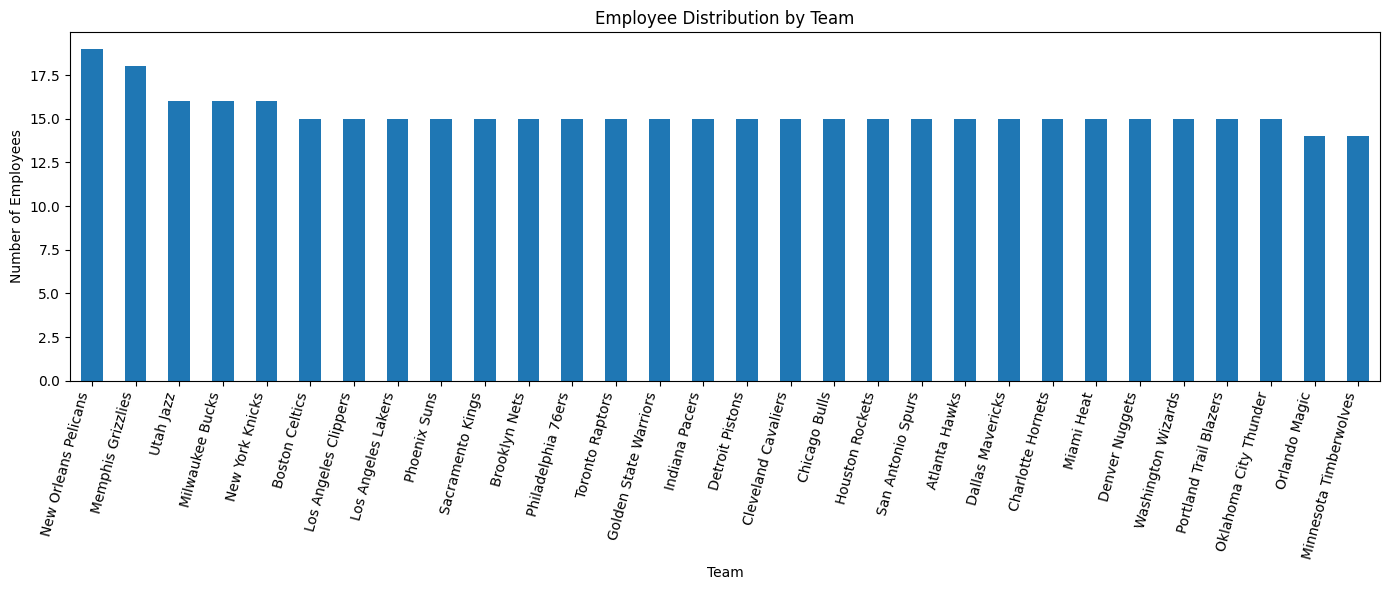

In [6]:
plt.figure(figsize=(14, 6))
team_counts.sort_values(ascending=False).plot(kind="bar")
plt.title("Employee Distribution by Team")
plt.xlabel("Team")
plt.ylabel("Number of Employees")
plt.xticks(rotation=75, ha="right")
plt.tight_layout()
plt.show()

### Answer

The **New Orleans Pelicans** have the highest number of employees: **19 employees (4.15%)**. Most teams have 15 employees.

## 6. Analysis 2 – Employees by Position

In [7]:
position_counts = df["Position"].value_counts()
display(position_counts.to_frame("Employee Count"))

print("Most common position:", position_counts.idxmax())
print("Number of employees:", position_counts.max())

,Employee Count
Position,
SG,102
PF,100
PG,92
SF,85
C,79


Most common position: SG
Number of employees: 102


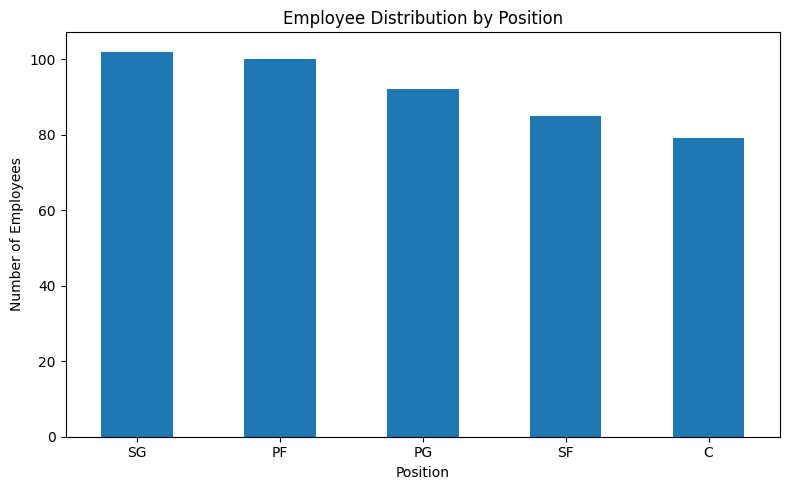

In [8]:
plt.figure(figsize=(8, 5))
position_counts.plot(kind="bar")
plt.title("Employee Distribution by Position")
plt.xlabel("Position")
plt.ylabel("Number of Employees")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Answer

The **SG** position has the highest number of employees with **102 employees**.

- SG: 102
- PF: 100
- PG: 92
- SF: 85
- C: 79

## 7. Analysis 3 – Predominant Age Group

In [9]:
age_bins = [0, 19, 25, 30, 35, 40, 100]
age_labels = ["<=19", "20-25", "26-30", "31-35", "36-40", "41+"]

df["Age Group"] = pd.cut(
    df["Age"], bins=age_bins, labels=age_labels, include_lowest=True
)

age_group_counts = df["Age Group"].value_counts().sort_index()
display(age_group_counts.to_frame("Employee Count"))

print("Predominant age group:", age_group_counts.idxmax())
print("Number of employees:", age_group_counts.max())

,Employee Count
Age Group,
<=19,2
20-25,198
26-30,167
31-35,68
36-40,23
41+,0


Predominant age group: 20-25
Number of employees: 198


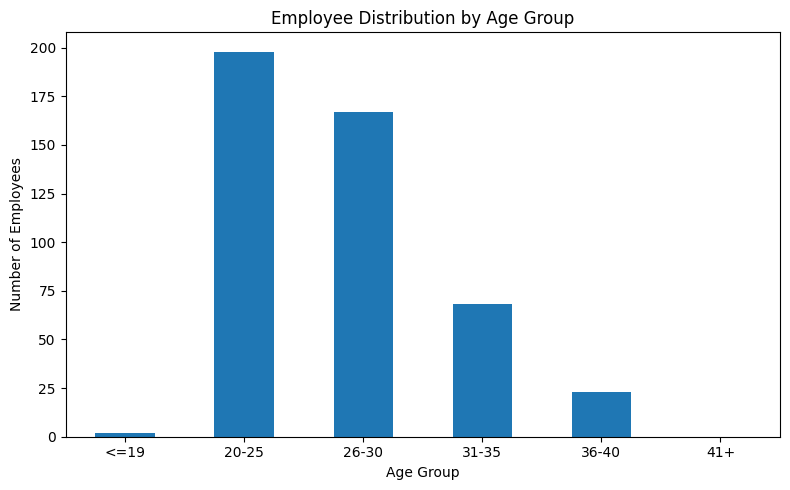

In [10]:
plt.figure(figsize=(8, 5))
age_group_counts.plot(kind="bar")
plt.title("Employee Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Employees")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Answer

The predominant age group is **20–25 years**, with **198 employees**.

## 8. Analysis 4 – Highest Salary Expenditure

In [11]:
team_salary = df.groupby("Team")["Salary"].sum().sort_values(ascending=False)
position_salary = df.groupby("Position")["Salary"].sum().sort_values(ascending=False)

print("Top 10 teams by salary expenditure:")
display(team_salary.head(10).to_frame("Total Salary"))

print("Salary expenditure by position:")
display(position_salary.to_frame("Total Salary"))

print("Highest salary expenditure team:", team_salary.idxmax())
print("Highest team expenditure: $", f"{team_salary.max():,.2f}")

print("Highest salary expenditure position:", position_salary.idxmax())
print("Highest position expenditure: $", f"{position_salary.max():,.2f}")

Top 10 teams by salary expenditure:


,Total Salary
Team,
Cleveland Cavaliers,"106,988,689.00"
Los Angeles Clippers,"94,854,640.00"
Oklahoma City Thunder,"93,765,298.00"
Golden State Warriors,"88,868,997.00"
Chicago Bulls,"86,783,378.00"
San Antonio Spurs,"84,442,733.00"
New Orleans Pelicans,"82,750,774.00"
Miami Heat,"82,515,673.00"
Charlotte Hornets,"78,340,920.00"


Salary expenditure by position:


,Total Salary
Position,
C,"466,377,332.00"
PG,"446,848,971.00"
PF,"442,560,850.00"
SF,"408,020,976.00"
SG,"396,976,258.00"


Highest salary expenditure team: Cleveland Cavaliers
Highest team expenditure: $ 106,988,689.00
Highest salary expenditure position: C
Highest position expenditure: $ 466,377,332.00


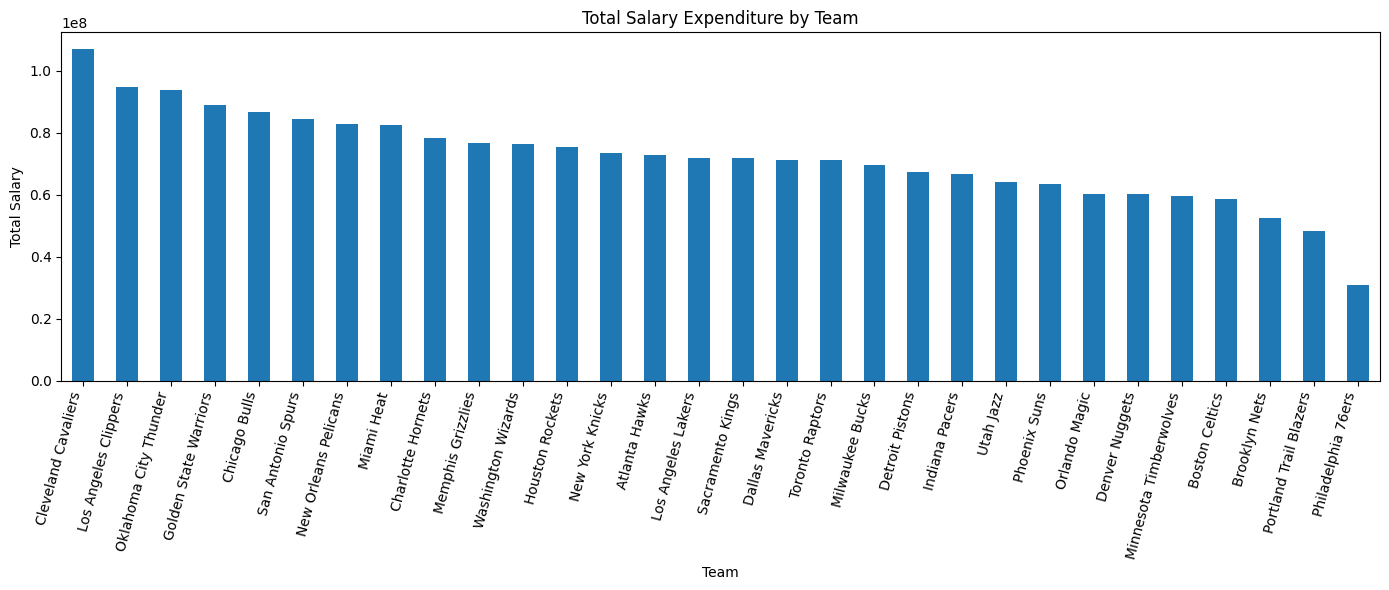

In [12]:
plt.figure(figsize=(14, 6))
team_salary.plot(kind="bar")
plt.title("Total Salary Expenditure by Team")
plt.xlabel("Team")
plt.ylabel("Total Salary")
plt.xticks(rotation=75, ha="right")
plt.tight_layout()
plt.show()

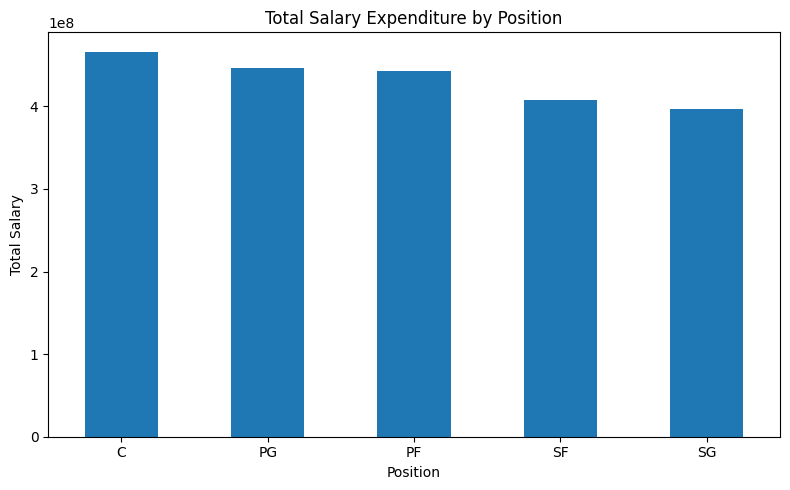

In [13]:
plt.figure(figsize=(8, 5))
position_salary.plot(kind="bar")
plt.title("Total Salary Expenditure by Position")
plt.xlabel("Position")
plt.ylabel("Total Salary")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Answer

- **Cleveland Cavaliers** have the highest team salary expenditure: **$106,988,689.00**.
- **C (Center)** has the highest position salary expenditure: **$466,377,332.00**.

## 9. Analysis 5 – Correlation Between Age and Salary

In [14]:
correlation = df["Age"].corr(df["Salary"])
print("Correlation coefficient:", round(correlation, 4))

Correlation coefficient: 0.214


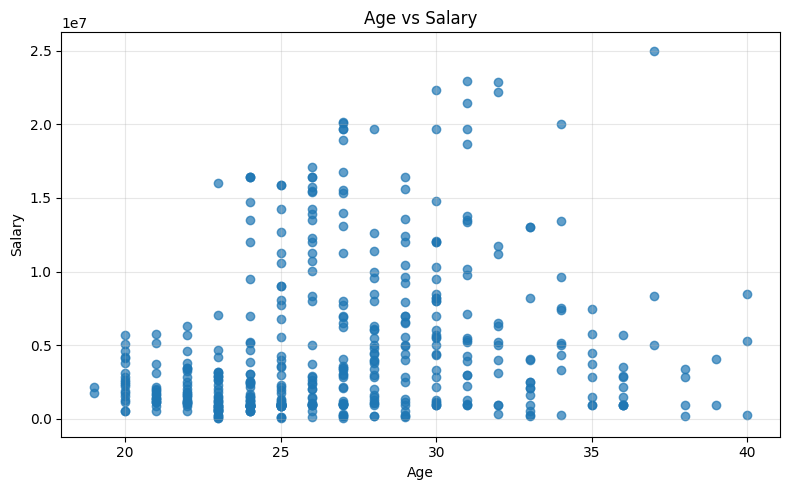

In [15]:
plt.figure(figsize=(8, 5))
plt.scatter(df["Age"], df["Salary"], alpha=0.7)
plt.title("Age vs Salary")
plt.xlabel("Age")
plt.ylabel("Salary")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Answer

The correlation coefficient is **0.2140**. This indicates a **weak positive correlation** between age and salary. Therefore, age has some positive relationship with salary, but age alone does not strongly determine salary.

# 10. Data Story – Key Insights

- Employee distribution is fairly balanced across most teams.
- The New Orleans Pelicans have the largest employee count.
- SG is the most common position.
- The 20–25 age group is the predominant age group.
- Cleveland Cavaliers have the highest total salary expenditure among teams.
- Center (C) has the highest total salary expenditure among positions.
- Age and salary show a weak positive correlation.
- The graphs make the major patterns and relationships easier to understand.

# Conclusion

The ABC Company dataset was successfully preprocessed and analyzed using Pandas, NumPy and Matplotlib. The analysis covers team distribution, position distribution, age groups, salary expenditure and the relationship between age and salary.

## GitHub Submission Files

Upload these three files to the repository:
1. `ABC_Company_End_Project_Completed.ipynb`
2. `ABC Company.xlsx`
3. `README.md`